<a href="https://colab.research.google.com/github/lawho13/ML_Pricing/blob/main/linear_model_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import ElasticNet
from collections import defaultdict
%pip install kneed
from sklearn.decomposition import PCA
from kneed import KneeLocator
import matplotlib.dates as mdates
from scipy.optimize import minimize


path = "/content/drive/My Drive/ML Asset Pricing/cleaned.csv"

Mounted at /content/drive


BACKTEST FOR LINEAR MODELS

In [ ]:
def load(path):
  # load csv into a pd dataframe; cast values to np.float32's for memory purposes; turn values in date to proper datetime objects; sort rows by permno, and inside permno groups, date
  df = pd.read_csv(path, dtype={col: np.float32 for col in pd.read_csv(path, nrows=0).columns if col not in ['DATE', 'year_month', 'permno']})
  df['DATE'] = pd.to_datetime(df['DATE'])
  df['year_month'] = pd.to_datetime(df['year_month']).dt.to_period('M')
  df = df.sort_values(['permno', 'DATE']).reset_index(drop=True)

  print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
  print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")

  return df


In [ ]:
clean = load(path)

Memory: 1.23 GB
Loaded 3016262 rows and 99 columns


In [ ]:
def split(df, initial_train_years=10, val_years=1, test_years=1, date_col='DATE'):

  # sort all rows in the dataframe by their dates
  # indicator_matrix['DATE']=pd.to_datetime(indicator_matrix['DATE'], errors='coerce', format = '%Y%m%d')
  # indicator_matrix= indicator_matrix.drop(columns=['DATE_NA', 'permno_NA'])

  # df = pd.merge(left = df,
  #               right = indicator_matrix,
  #               on =['permno', 'DATE'],
  #               how = 'left',
  #               suffixes=('', '_NA'))

  df = df.sort_values(date_col).reset_index(drop=True)

  start_date = df[date_col].min()
  end_date   = df[date_col].max()

  # let the current train_end be start_date plus the arg from the constructor for train years

  train_end = start_date + pd.DateOffset(years=initial_train_years)

  while True:
      # the backtesting loop - here, we set val_end to the date train_end + val from constructor, likewise with test_end
      val_end  = train_end + pd.DateOffset(years=val_years)
      test_end = val_end   + pd.DateOffset(years=test_years)

      # if this is the case, we've exceeded window length - break
      if test_end > end_date:
          break

      # these are all the valid data frames to return - we have a training dataframe, a validation data frame, and a test data frame - all within their respective date timelines
      train_df = df[df[date_col] <  train_end]
      val_df   = df[(df[date_col] >= train_end) & (df[date_col] < val_end)]
      test_df  = df[(df[date_col] >= val_end)   & (df[date_col] < test_end)]

      print(
          f"Train: {train_df[date_col].min().date()} → {train_df[date_col].max().date()} "
          f"({len(train_df)} rows) | "
          f"Val: {val_df[date_col].min().date()} → {val_df[date_col].max().date()} | "
          f"Test: {test_df[date_col].min().date()} → {test_df[date_col].max().date()}"
      )

      # in tuple format, return the data frames
      yield train_df, val_df, test_df

      # set train_end to test_end to adjust the window and move the time series window up for another testing round
      train_end = test_end

def get_features_and_target(df, target_col='ret'):
  drop_cols = ['DATE', 'year_month', 'permno', 'DATE_NA', 'permno_NA', target_col]
  feature_cols = [c for c in df.columns if c not in drop_cols]
  temp_df = df.dropna(subset=feature_cols + [target_col])

  X = temp_df[feature_cols].values
  y = temp_df[target_col].values

  return X, y

The Workflow for your Forecast:
Step 1: Run your tuning loop on the very last available window (e.g., Train 1985–2024, Val 2025).
Step 2: Find the "Optimal" params for that specific moment (e.g., $\alpha=0.01, l1=0.1$).
Step 3: Use those specific params to train on all data up to today.
Step 4: Predict next month.

In [ ]:
def huber_loss_ols(theta, X, y, xi):
  """
  theta : coefficient vector INCLUDING intercept
  X     : feature matrix WITH intercept column
  y     : target vector
  xi    : huber threshold
  """

  residuals = y - X @ theta
  abs_resid = np.abs(residuals)

  loss = np.where(
      abs_resid <= xi,
      residuals**2,
      2 * xi * abs_resid - xi**2
  )

  return np.mean(loss)

def huber_ols(X, y, delta):
  '''
  X: already has intercept
  delta: threshold for Huber loss
  y: response
  '''
  beta0 = np.zeros(X.shape[1])
  result = minimize(huber_loss_ols, beta0, args=(X, y, delta))
  return result.x

def huber_pred(X, beta):
  return X @ beta


In [ ]:
ols_oos_results = []
olsh_oos_results = []

for train, val, test in split(clean):
  X_train, y_train = get_features_and_target(train)
  X_val, y_val  = get_features_and_target(val)
  X_test, y_test  = get_features_and_target(test)

  X_train_constant = sm.add_constant(X_train)
  X_val_constant  = sm.add_constant(X_val)
  X_test_constant = sm.add_constant(X_test)

  model = sm.OLS(y_train, X_train_constant).fit()
  train_pred = model.predict(X_train_constant) # train pred
  val_pred = model.predict(X_val_constant) # val pred
  r2_val_ols = r2_score(y_val, val_pred)
  mse_val_ols = mean_squared_error(y_val, val_pred)

  # OLS prediction
  y_pred = model.predict(X_test_constant)
  r2_test_ols = r2_score(y_test, y_pred)
  mse_test_ols = mean_squared_error(y_test, y_pred)

  # Huber Loss OLS
  resid = y_train - train_pred # param
  delta = np.quantile(np.abs(resid), 0.999) # param

  model_huber = huber_ols(X_train_constant, y_train, delta) # Huber
  y_val_pred_huber = huber_pred(X_val_constant, model_huber) # Huber

  r2_huber_val = r2_score(y_val, y_val_pred_huber)
  mse_huber_val = mean_squared_error(y_val, y_val_pred_huber)
  y_pred_huber = huber_pred(X_test_constant, model_huber)
  r2_huber = r2_score(y_test, y_pred_huber)
  mse_huber = mean_squared_error(y_test, y_pred_huber)


  olsh_oos_results.append({
      'val_start': val['DATE'].min().date(),
      'val_end': val['DATE'].max().date(),

      'test_start': test['DATE'].min().date(),
      'test_end': test['DATE'].max().date(),

      'r2_val': r2_huber_val,
      'mse_val': mse_huber_val,

      'mse_test': mse_huber,
      'r2_test': r2_huber
  })

  ols_oos_results.append({
      'val_start': val['DATE'].min().date(),
      'val_end': val['DATE'].max().date(),

      'test_start': test['DATE'].min().date(),
      'test_end': test['DATE'].max().date(),

      'r2_val': r2_val_ols,
      'mse_val': mse_val_ols,

      'mse_test': mse_test_ols,
      'r2_test': r2_test_ols
  })

# print(f"Window {test['DATE'].max().year} | OOS R^2: {r2_test}")

# Just visually checking the linear OLS model

Train: 1985-01-31 → 1994-12-30 (828888 rows) | Val: 1995-01-31 → 1995-12-29 | Test: 1996-01-31 → 1996-12-31
Train: 1985-01-31 → 1996-12-31 (1032247 rows) | Val: 1997-01-31 → 1998-01-30 | Test: 1998-02-27 → 1999-01-29
Train: 1985-01-31 → 1999-01-29 (1257329 rows) | Val: 1999-02-26 → 1999-12-31 | Test: 2000-01-31 → 2000-12-29
Train: 1985-01-31 → 2000-12-29 (1450226 rows) | Val: 2001-01-31 → 2001-12-31 | Test: 2002-01-31 → 2002-12-31
Train: 1985-01-31 → 2002-12-31 (1629936 rows) | Val: 2003-01-31 → 2004-01-30 | Test: 2004-02-27 → 2004-12-31
Train: 1985-01-31 → 2004-12-31 (1791876 rows) | Val: 2005-01-31 → 2005-12-30 | Test: 2006-01-31 → 2006-12-29
Train: 1985-01-31 → 2006-12-29 (1953636 rows) | Val: 2007-01-31 → 2007-12-31 | Test: 2008-01-31 → 2009-01-30
Train: 1985-01-31 → 2009-01-30 (2120808 rows) | Val: 2009-02-27 → 2010-01-29 | Test: 2010-02-26 → 2010-12-31
Train: 1985-01-31 → 2010-12-31 (2254126 rows) | Val: 2011-01-31 → 2011-12-30 | Test: 2012-01-31 → 2012-12-31
Train: 1985-01-31 → 

In [ ]:
# Huber Loss extension
# Robust to Outliers

def huber_loss(y_true, y_pred, delta):
  error = y_true - y_pred
  loss = np.where(
      np.abs(error) <= delta,
      error**2,
      2*np.abs(error)*delta - delta**2
  )
  return np.mean(loss)

In [ ]:
en_oos_results = []
enh_oos_results = []

# Hyperparameter grids
alpha_grid = [0.0001, 0.001, 0.01]
l1_ratio_grid = [0.1, 0.5, 0.9]

for train, val, test in split(clean):
  X_train, y_train = get_features_and_target(train)
  X_val, y_val     = get_features_and_target(val)
  X_test, y_test   = get_features_and_target(test)

  # Track best standard EN model
  best_val_mse = np.inf
  best_en_model = None
  best_en_alpha = None
  best_en_l1 = None

  # Track best Huber-selected EN model
  best_val_huber = np.inf
  best_enh_model = None
  best_enh_alpha = None
  best_enh_l1 = None

  # Hyperparameter search
  for alpha in alpha_grid:
    for l1_ratio in l1_ratio_grid:

      # Fit Elastic Net
      model = ElasticNet(
          alpha=alpha,
          l1_ratio=l1_ratio,
          fit_intercept=True,
          max_iter=10000
      )

      model.fit(X_train, y_train)
      y_val_pred = model.predict(X_val)

      # Validation predictions
      y_train_pred = model.predict(X_train)

      # EN MSE
      val_mse = mean_squared_error(y_val, y_val_pred)
      if val_mse < best_val_mse:

          best_val_mse = val_mse
          best_en_model = model
          best_en_alpha = alpha
          best_en_l1 = l1_ratio

  # EN Huber selection

  resid = y_train - y_train_pred
  delta = np.quantile(np.abs(resid), 0.999)

  val_huber = huber_loss(
      y_val,
      y_val_pred,
      delta
  )

  if val_huber < best_val_huber:

      best_val_huber = val_huber
      best_enh_model = model
      best_enh_alpha = alpha
      best_enh_l1 = l1_ratio

  # MSE EN Evaluation
  en_val_pred = best_en_model.predict(X_val)
  en_test_pred = best_en_model.predict(X_test)

  en_oos_results.append({

      'test_start': test['DATE'].min().date(),
      'test_end': test['DATE'].max().date(),

      'best_alpha': best_en_alpha,
      'best_l1_ratio': best_en_l1,

      'mse_val': best_val_mse,
      'r2_val': r2_score(y_val, en_val_pred),

      'mse_test': mean_squared_error(y_test, en_test_pred),
      'r2_test': r2_score(y_test, en_test_pred)

  })

  # Huber EN Evaluation
  enh_val_pred = best_enh_model.predict(X_val)
  enh_test_pred = best_enh_model.predict(X_test)

  enh_oos_results.append({

      'test_start': test['DATE'].min().date(),
      'test_end': test['DATE'].max().date(),

      'best_alpha': best_enh_alpha,
      'best_l1_ratio': best_enh_l1,

      'huber_val': best_val_huber,
      'r2_val': r2_score(y_val, enh_val_pred),

      'mse_test': mean_squared_error(y_test, enh_test_pred),
      'r2_test': r2_score(y_test, enh_test_pred)

  })

Train: 1985-01-31 → 1994-12-30 (828888 rows) | Val: 1995-01-31 → 1995-12-29 | Test: 1996-01-31 → 1996-12-31
Train: 1985-01-31 → 1996-12-31 (1032247 rows) | Val: 1997-01-31 → 1998-01-30 | Test: 1998-02-27 → 1999-01-29
Train: 1985-01-31 → 1999-01-29 (1257329 rows) | Val: 1999-02-26 → 1999-12-31 | Test: 2000-01-31 → 2000-12-29
Train: 1985-01-31 → 2000-12-29 (1450226 rows) | Val: 2001-01-31 → 2001-12-31 | Test: 2002-01-31 → 2002-12-31
Train: 1985-01-31 → 2002-12-31 (1629936 rows) | Val: 2003-01-31 → 2004-01-30 | Test: 2004-02-27 → 2004-12-31
Train: 1985-01-31 → 2004-12-31 (1791876 rows) | Val: 2005-01-31 → 2005-12-30 | Test: 2006-01-31 → 2006-12-29
Train: 1985-01-31 → 2006-12-29 (1953636 rows) | Val: 2007-01-31 → 2007-12-31 | Test: 2008-01-31 → 2009-01-30
Train: 1985-01-31 → 2009-01-30 (2120808 rows) | Val: 2009-02-27 → 2010-01-29 | Test: 2010-02-26 → 2010-12-31
Train: 1985-01-31 → 2010-12-31 (2254126 rows) | Val: 2011-01-31 → 2011-12-30 | Test: 2012-01-31 → 2012-12-31
Train: 1985-01-31 → 

In [ ]:
# @title
# def prox(theta, lmbda, rho, gamma):
#   denom = 1+(lmbda*rho*gamma)
#   mu = (1-rho)*lmbda*gamma
#   s_theta = np.sign(theta) * np.maximum(np.abs(theta) - mu, 0)

#   return s_theta/denom

# def elasticnet(X, y, lmbda, rho, gamma=0.001, delta = 1e-6):
#   # Initialize
#   n = X.shape[0]
#   m = 0
#   theta_curr = np.zeros(X.shape[1]) # columns
#   theta_next = np.zeros(X.shape[1]) # This variable is initialized but never used.
#   max_iter = 5000

#   # theta_next = theta_curr.copy()

#   while m < max_iter:
#     gradient = -(1/n) * X.T @ (y - X @ theta_curr)
#     theta_bar = theta_curr - gamma*gradient

#     theta_tilde = prox(theta_bar, lmbda, rho, gamma)

#     theta_next =  theta_tilde + (m / (m + 3)) * (theta_tilde - theta_curr)

#     if np.linalg.norm(theta_next - theta_curr) < delta:
#             break

#     theta_curr = theta_next
#     m = m+1

#   return theta_next # Weights

In [ ]:
# @title
# en_oos_results = []

# for train, val, test in split(clean, indicator_matrix):
#   best_model = None
#   best_mse = float('inf')
#   best_l = None
#   best_r = None
#   X_train, y_train = get_features_and_target(train)
#   X_val, y_val  = get_features_and_target(val)

#   X_train_constant = sm.add_constant(X_train)
#   X_val_constant  = sm.add_constant(X_val)
#   # print(y_train.shape, X_train_constant.shape)
#   lmbda = [0.0001, 0.001, 0.01]
#   rho = [0.1, 0.5, 0.9]
#   for l in lmbda:
#       for r in rho:
#         model = elasticnet(X_train_constant, y_train, l, r)
#         y_pred = X_val_constant@model

#         # r2 = r2_score(y_val, y_pred)
#         val_mse = mean_squared_error(y_val, y_pred)

#         if val_mse < best_mse:
#           best_mse = val_mse
#           best_l = l
#           best_r = r
#           best_model = model

#   en_oos_results.append({
#       'val_start': val['DATE'].min().date(),
#       'val_end': val['DATE'].max().date(),
#       'param': (best_l, best_r),
#       'mse_val': best_mse
#   })

#   print(f"Window {val['DATE'].max().year} | val_mse: {best_mse}")


In [ ]:
en_oos_results_df = pd.DataFrame(en_oos_results)
enh_oos_results_df = pd.DataFrame(enh_oos_results)

In [ ]:
en_oos_results_df[['best_alpha', 'best_l1_ratio']].value_counts()
enh_oos_results_df[['best_alpha', 'best_l1_ratio']].value_counts()

,,count
best_alpha,best_l1_ratio,
0.01,0.9,13


In [ ]:
# PCR (Principle Component Regression)

def optimal_components(X_train, y_train, X_val, y_val):
  pca = PCA()

  pca.fit(X_train)
  explained_variance = pca.explained_variance_ratio_
  cumulative_variance = np.cumsum(explained_variance)

  max_pcs = min(20, X_train.shape[1])
  pcs = np.arange(1, max_pcs + 1)

  explained_variance = explained_variance[:max_pcs]

  kneedle = KneeLocator( pcs, explained_variance, curve="convex", direction="decreasing" )
  knee_val = kneedle.knee

  return knee_val

def pca_model():
  pcr_oos_results = []
  for train, val, test in split(clean):
    X_train, y_train = get_features_and_target(train)
    X_val, y_val = get_features_and_target(val)

    optimal_k = optimal_components(X_train, y_train, X_val, y_val)

    pca = PCA(n_components=optimal_k)
    pca.fit(X_train)

    X_train_pca = pca.transform(X_train)
    X_val_pca = pca.transform(X_val)
    X_test_pca = pca.transform(X_test)

    X_train_constant = sm.add_constant(X_train_pca)
    X_val_constant  = sm.add_constant(X_val_pca)
    X_test_constant = sm.add_constant(X_test_pca)


    model = sm.OLS(y_train, X_train_constant).fit()
    y_pred = model.predict(X_test_constant)

    test_mse = mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)


    pcr_oos_results.append({
        'test_start': test['DATE'].min().date(),
        'test_end': test['DATE'].max().date(),
        'mse_test': test_mse,
        'r2_test': test_r2,
        'optimal_components':optimal_k
    })

    print(f"Window {val['DATE'].max().year}")

  return pcr_oos_results

pcr_oos_results = pca_model()

Train: 1985-01-31 → 1994-12-30 (828888 rows) | Val: 1995-01-31 → 1995-12-29 | Test: 1996-01-31 → 1996-12-31
Window 1995
Train: 1985-01-31 → 1996-12-31 (1032247 rows) | Val: 1997-01-31 → 1998-01-30 | Test: 1998-02-27 → 1999-01-29
Window 1998
Train: 1985-01-31 → 1999-01-29 (1257329 rows) | Val: 1999-02-26 → 1999-12-31 | Test: 2000-01-31 → 2000-12-29
Window 1999
Train: 1985-01-31 → 2000-12-29 (1450226 rows) | Val: 2001-01-31 → 2001-12-31 | Test: 2002-01-31 → 2002-12-31
Window 2001
Train: 1985-01-31 → 2002-12-31 (1629936 rows) | Val: 2003-01-31 → 2004-01-30 | Test: 2004-02-27 → 2004-12-31
Window 2004
Train: 1985-01-31 → 2004-12-31 (1791876 rows) | Val: 2005-01-31 → 2005-12-30 | Test: 2006-01-31 → 2006-12-29
Window 2005
Train: 1985-01-31 → 2006-12-29 (1953636 rows) | Val: 2007-01-31 → 2007-12-31 | Test: 2008-01-31 → 2009-01-30
Window 2007
Train: 1985-01-31 → 2009-01-30 (2120808 rows) | Val: 2009-02-27 → 2010-01-29 | Test: 2010-02-26 → 2010-12-31
Window 2010
Train: 1985-01-31 → 2010-12-31 (2

In [ ]:
# should be based on mse not just r2, r2 to evaluate test.

In [ ]:
linear_performance = {
    'ols': ols_oos_results,
    'ols_h': olsh_oos_results,
    'en': en_oos_results,
    'en_h': enh_oos_results,
    'pcr': pcr_oos_results
}

dfs = []
for name, res in linear_performance.items():
  df = pd.DataFrame(res)
  df['method'] = name.upper()
  dfs.append(df)

all_models_mse = pd.concat(dfs, ignore_index=True)
all_models_mse['test_start'] = pd.to_datetime(all_models_mse['test_start'])

display(all_models_mse.head())

,val_start,val_end,test_start,test_end,r2_val,mse_val,mse_test,r2_test,method,best_alpha,best_l1_ratio,huber_val,optimal_components
0,1995-01-31,1995-12-29,1996-01-31,1996-12-31,-0.003425,0.018366,0.020662,0.003258,OLS,NaN,NaN,NaN,NaN
1,1997-01-31,1998-01-30,1998-02-27,1999-01-29,0.006415,0.022232,0.034249,0.001792,OLS,NaN,NaN,NaN,NaN
2,1999-02-26,1999-12-31,2000-01-31,2000-12-29,-0.001157,0.036751,0.050762,-0.003392,OLS,NaN,NaN,NaN,NaN
3,2001-01-31,2001-12-31,2002-01-31,2002-12-31,0.001893,0.051728,0.030956,0.000447,OLS,NaN,NaN,NaN,NaN
4,2003-01-31,2004-01-30,2004-02-27,2004-12-31,-0.070141,0.023374,0.013113,-0.010261,OLS,NaN,NaN,NaN,NaN


In [ ]:
linear_performance = {
    'ols': ols_oos_results,
    'ols_h': olsh_oos_results,
    'en': en_oos_results,
    'en_h': enh_oos_results,
    'pcr': pcr_oos_results
}

# ---------------------------------------------------
# Convert ALL to DataFrames safely
# ---------------------------------------------------

dfs = []

for name, res in linear_performance.items():

    df = pd.DataFrame(res)

    df['method'] = name.upper()

    dfs.append(df)

# ---------------------------------------------------
# Combine everything
# ---------------------------------------------------

all_models_mse = pd.concat(dfs, ignore_index=True)

# Ensure datetime
all_models_mse['test_start'] = pd.to_datetime(all_models_mse['test_start'])

display(all_models_mse.head())

,val_start,val_end,test_start,test_end,r2_val,mse_val,mse_test,r2_test,method,best_alpha,best_l1_ratio,huber_val,optimal_components
0,1995-01-31,1995-12-29,1996-01-31,1996-12-31,-0.003425,0.018366,0.020662,0.003258,OLS,NaN,NaN,NaN,NaN
1,1997-01-31,1998-01-30,1998-02-27,1999-01-29,0.006415,0.022232,0.034249,0.001792,OLS,NaN,NaN,NaN,NaN
2,1999-02-26,1999-12-31,2000-01-31,2000-12-29,-0.001157,0.036751,0.050762,-0.003392,OLS,NaN,NaN,NaN,NaN
3,2001-01-31,2001-12-31,2002-01-31,2002-12-31,0.001893,0.051728,0.030956,0.000447,OLS,NaN,NaN,NaN,NaN
4,2003-01-31,2004-01-30,2004-02-27,2004-12-31,-0.070141,0.023374,0.013113,-0.010261,OLS,NaN,NaN,NaN,NaN


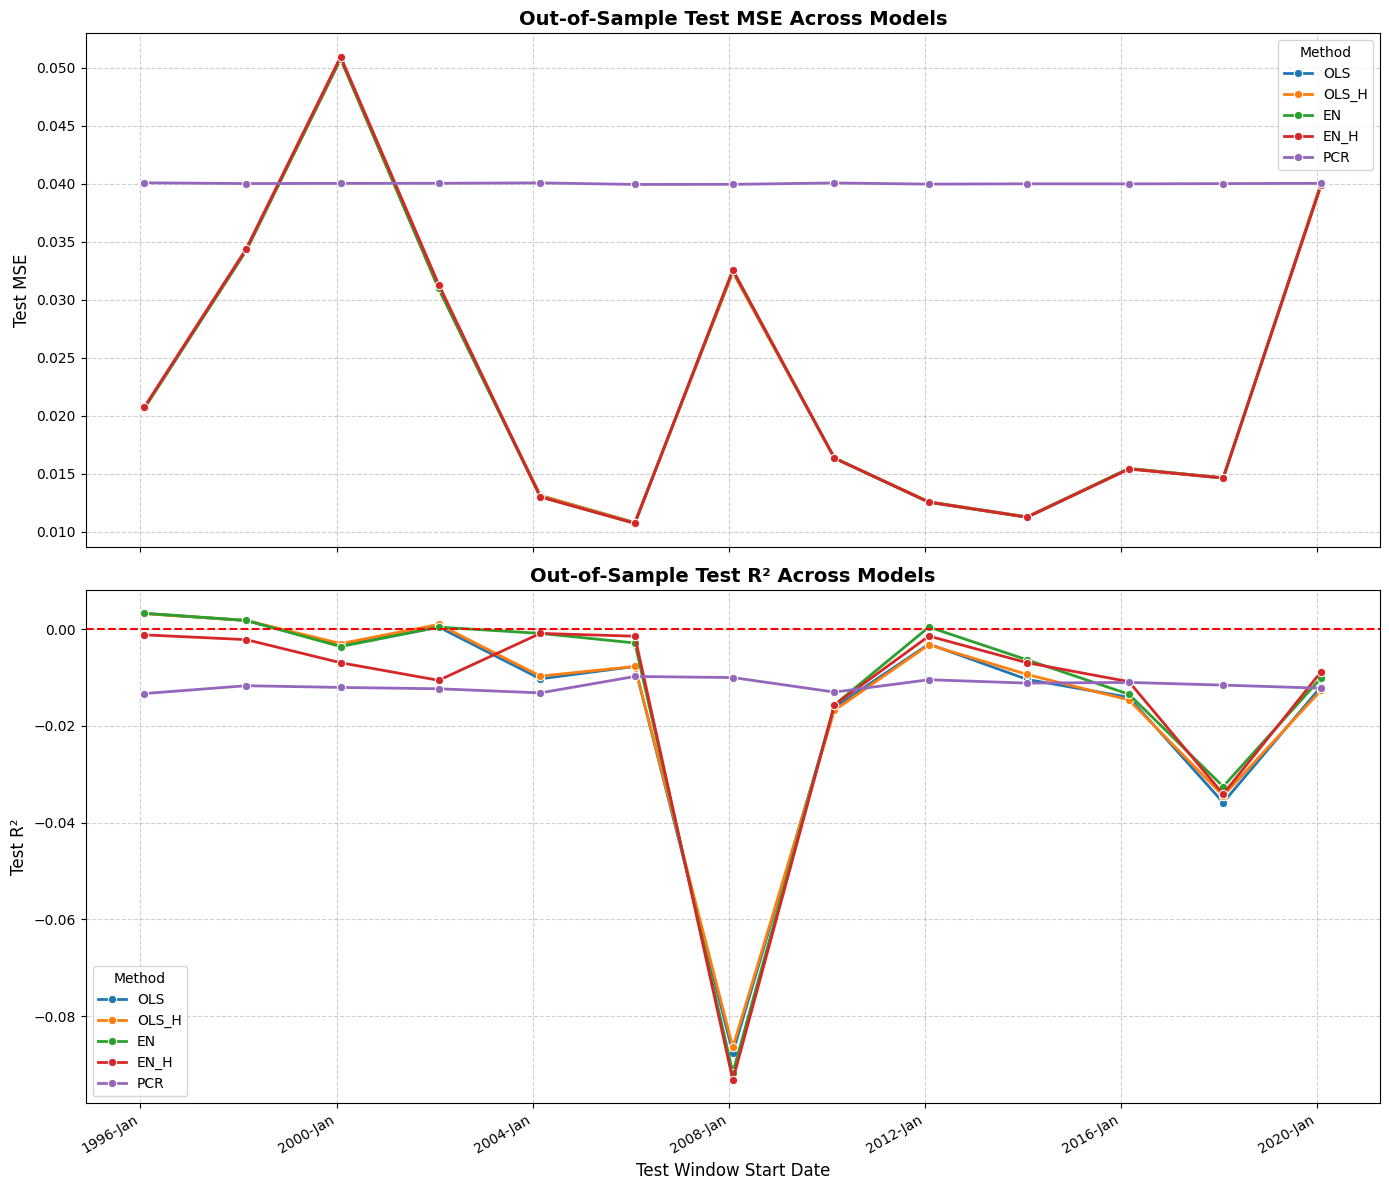

In [ ]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 12),
    sharex=True
)

# ---------------------------------------------------
# Plot TEST MSE
# ---------------------------------------------------

sns.lineplot(
    data=all_models_mse,
    x='test_start',
    y='mse_test',
    hue='method',
    marker='o',
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title(
    'Out-of-Sample Test MSE Across Models',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('Test MSE', fontsize=12)

axes[0].grid(True, linestyle='--', alpha=0.6)

axes[0].legend(title='Method')

# ---------------------------------------------------
# Plot TEST R²
# ---------------------------------------------------

sns.lineplot(
    data=all_models_mse,
    x='test_start',
    y='r2_test',
    hue='method',
    marker='o',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    'Out-of-Sample Test R² Across Models',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Test Window Start Date', fontsize=12)

axes[1].set_ylabel('Test R²', fontsize=12)

axes[1].grid(True, linestyle='--', alpha=0.6)

# Reference line at R² = 0
axes[1].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

axes[1].legend(title='Method')

# ---------------------------------------------------
# Format dates
# ---------------------------------------------------

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%b')
)

fig.autofmt_xdate()

plt.tight_layout()

In [ ]:
# all_models_mse.to_csv('/content/drive/My Drive/ML Asset Pricing/linear_models.csv', index=False)
#